Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Trabajo Práctico N°1**

El objetivo de este trabajo práctico es realizar un análisis completo del ciclo de vida de un problema de Machine Learning, centrándose en la preparación de los datos, la prevención de Data Leakage, la estrategia de validación y la correcta elección de métricas orientadas al negocio.

A continuación, importamos los módulos correspondientes con los que trabajaremos y conjunto de datos.

In [1]:
# Importamos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importamos el dataset de Telco Customer Churn
dataset:pd.DataFrame = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Imprimimos las primeras cinco filas
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Parte I: El Camino de los Datos (Telco Churn)**

### **1. Introducción al problema y Análisis Exploratorio**

#### **Descripción de los datos y el problema a resolver**

Los datos provistos nos hablan acerca de un registro de clientes de la empresa Telco. Cada fila representa un usuario junto con una serie de características, entre las cuales se encuentra el atributo de `churn`, que nos indica si dicho cliente abandono o no el servicio en el último mes.

El problema a resolver sobre el cual trabajaremos consiste en predecir si un usuario esta o no por abandonar el servicio (*Churn Prediction*). Esta clasificación se logra a partir de distinguir qué características predominan entre los usuarios que abandonaron.

#### **Análisis exploratorio**

Primero que nada, analicemos las columnas que disponemos.

In [3]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Procedemos con un análisis exhaustivo del conjunto de datos para entender como se comportan.

In [4]:
# Dimensiones del dataset
print('Dimensionas del dataset:', dataset.shape)
print('Columnas del dataset:', dataset.columns)

Dimensionas del dataset: (7043, 21)
Columnas del dataset: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


Podemos observar que el dataset que disponemos cuenta con **7043 muestras** y cada una cuenta con **21 features**.

In [5]:
# Aislamos la columna `churn` para ver como se distribuyen las clases (Yes/No)
churn:pd.DataFrame = pd.DataFrame(dataset['Churn'])
churn.value_counts()

Churn
No       5174
Yes      1869
Name: count, dtype: int64

Notamos un **gran desbalance entre las clases `Yes` y `No`en la feature `Churn`** ya que la mayoria de los usuarios recolectados para el dataset les corresponde la clase `No`, es decir, son usuarios que no abandonaron el servicio en el último mes. Luego, `No` es la clase mayoritaría y `Yes` la clase minoritaria.

Para explícitar este desbalance vamos a proceder con un bar-plot.

<Axes: xlabel='Churn', ylabel='count'>

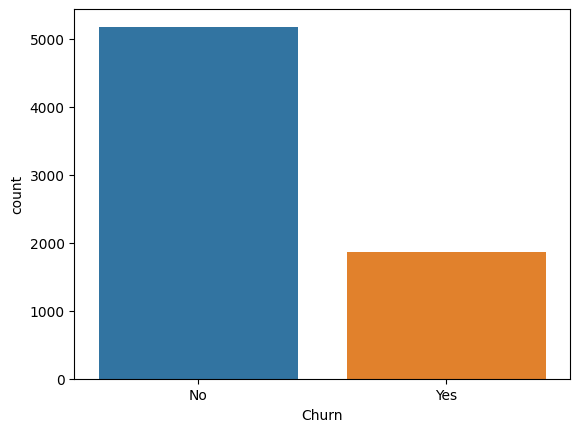

In [6]:
# Gráfico de barras (cantidad )
sns.countplot(x='Churn', data=dataset)

/media/arotu/HDD/Facultad/UTDT/S2_2026/TD VI/TD-VI-TP1/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tenure', ylabel='Count'>

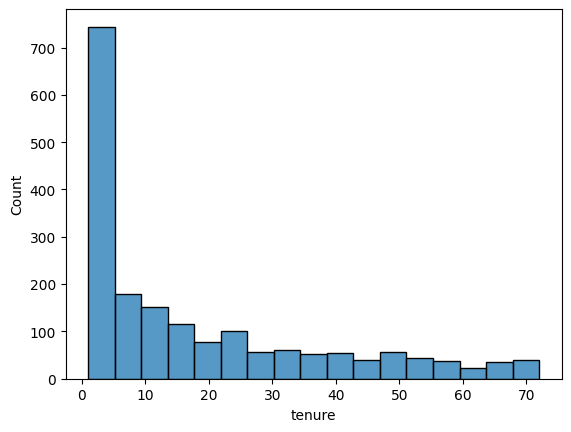

In [7]:
# Gráfico de
dataset_filtrado_yes = dataset[dataset['Churn'] == 'Yes']
sns.histplot(x='tenure', data=dataset_filtrado_yes)

/media/arotu/HDD/Facultad/UTDT/S2_2026/TD VI/TD-VI-TP1/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tenure', ylabel='Count'>

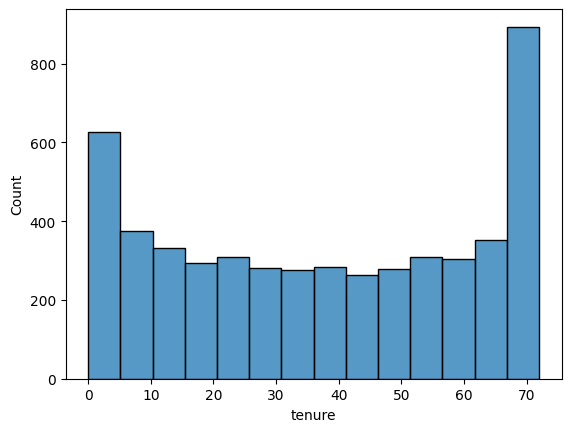

In [8]:
dataset_filtrado_no = dataset[dataset['Churn'] == 'No']
sns.histplot(x='tenure', data=dataset_filtrado_no)

#### **Sobre la carga de columnas como datos no númericos**

### **2. Preprocesamiento y prevención de Data Leakage**

#### **Valores faltantes**

#### **Vaiables categóricas y Feature Scaling**

#### **Sobre el orden de las operaciones y su relación con la division del dataset**

### **3. Estrategia de Validación**

#### **Implementación de $k$-Fold Cross-Validation**

#### **Sobre estrategias de validación del modelo**

### **4. Evaluación del modelo base**